- What strategy does the unmatching player follow? Do they tend to rapidly shift their cursor back and forth between the 2 zones, or feign going to one zone before switching their cursor suddenly to the other? This could be assessed by investigating the variation in cursor position in the seconds prior to trial cutoff. Overall lower variability in cursor position might indicate feigning and sudden movement.

## First-pass analysis: the unmatching (avoider) player's strategy

The avoider wins by **not** sharing a zone with the matcher when the trial ends
at a *uniformly-random* time (`random_time_ms`), so it can never just settle
early. Two candidate strategies (from the hypothesis above):

1. **Oscillate** – rapidly shuttle between L and R the whole trial &rarr; high cursor-position variability.
2. **Feint + switch** – sit on one side, then make a single sudden switch &rarr; low variability, then one sharp move.

We summarise each avoider trial's cursor trace, classify the behaviour, and ask
**which strategy dominates** and **which one actually wins**.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from parse_games import build_all

tables = build_all()
trials, cursor_samples = tables["trials"], tables["cursor_samples"]

# matching-pennies trials (indexed for lookup) and the avoider's cursor samples
mp = trials[trials.game == "matching_pennies"].set_index("trial")
avoider = cursor_samples[(cursor_samples.game == "matching_pennies")
                         & (cursor_samples.role == "avoider")].copy()

print(f"{len(mp)} trials | avoider won {int(mp.avoider_won.sum())}/{len(mp)} "
      f"({mp.avoider_won.mean():.0%}) | {len(avoider)} cursor samples")
mp[["matcher_action", "avoider_action", "matched",
    "avoider_won", "random_time_ms"]].head()

100 trials | avoider won 53/100 (53%) | 10856 cursor samples


,matcher_action,avoider_action,matched,avoider_won,random_time_ms
trial,,,,,
1,NONE,NONE,False,False,2815
2,R,NONE,False,False,3222
3,R,NONE,False,False,3466
4,L,NONE,False,False,4348
5,R,L,False,True,2379


### Per-trial movement features

For each trial we summarise the avoider's cursor-x trace (`x`: 0 = far left,
1 = far right; the middle band is the no-choice zone). Each feature notes the
window it is measured over — **[full trial]** or **[final 1 s before cutoff]**:

* **`n_switch`** *[full trial]* – number of committed L&harr;R switches (collapsing the middle) &rarr; oscillation count.
* **`x_std_all`** *[full trial]* – cursor-x SD over the whole trial.
* **`x_std_last1s`** *[final 1 s]* – cursor-x SD over only the last second before the random cutoff.
* **`peak_speed`** *[full trial]* – fastest |&Delta;x|/&Delta;t, i.e. how *sudden* the biggest move was.
* **`path_len`** *[full trial]* – total horizontal distance travelled.

In [3]:
def avoider_features(tr, g):
    """One row of trajectory summary stats for avoider trial `tr`."""
    g = g.sort_values("t_ms")
    x, t_ms = g.x.values, g.t_ms.values
    dur = mp.loc[tr, "random_time_ms"]            # random cutoff for this trial

    # committed-zone sequence -> number of L<->R switches
    committed = [z for z in g.zone.values if z in ("L", "R")]
    seq = [z for i, z in enumerate(committed) if i == 0 or z != committed[i - 1]]
    n_switch = max(len(seq) - 1, 0)

    def sd_last(win_ms):                            # cursor-x SD in the window before cutoff
        m = t_ms >= dur - win_ms
        return np.std(x[m]) if m.sum() > 1 else np.nan

    dt = np.diff(t_ms) / 1000.0                     # speed = |dx| per second
    speed = np.abs(np.diff(x)) / np.where(dt > 0, dt, np.nan)

    return pd.Series(dict(
        dur_ms=dur,
        x_std_all=np.std(x),
        x_std_last1s=sd_last(1000),
        path_len=np.sum(np.abs(np.diff(x))),
        peak_speed=np.nanmax(speed) if len(speed) else 0.0,
        n_switch=n_switch,
        ever_committed=len(committed) > 0,
        final_zone=mp.loc[tr, "avoider_action"],
        won=bool(mp.loc[tr, "avoider_won"]),
    ))

af = pd.DataFrame({tr: avoider_features(tr, g)
                   for tr, g in avoider.groupby("trial")}).T
af.index.name = "trial"
af[["dur_ms", "x_std_all", "x_std_last1s", "path_len", "peak_speed", "n_switch"]] = (
    af[["dur_ms", "x_std_all", "x_std_last1s", "path_len", "peak_speed", "n_switch"]]
    .apply(pd.to_numeric))
af.head()

,dur_ms,x_std_all,x_std_last1s,path_len,peak_speed,n_switch,ever_committed,final_zone,won
trial,,,,,,,,,
1,2815,0.000000,0.000000,0.000000,0.000000,0,False,NONE,False
2,3222,0.000000,0.000000,0.000000,0.000000,0,False,NONE,False
3,3466,0.000000,0.000000,0.000000,0.000000,0,False,NONE,False
4,4348,0.137780,0.009783,2.454687,10.006010,0,True,NONE,False
5,2379,0.263198,0.226125,2.141797,10.259651,1,True,L,True


### Four behavioural categories

Classify each trial from its committed-zone switch count:

| category | rule |
|---|---|
| **middle (no commit)** | never enters L or R (sits in the no-choice band) |
| **hold one side** | commits once, never switches |
| **feint + switch** | exactly one switch — *feign then move* |
| **oscillate (2+)** | two or more switches — *rapid back-and-forth* |

In [4]:
def categorise(r):
    if not r.ever_committed: return "middle (no commit)"
    if r.n_switch == 0:      return "hold one side"
    if r.n_switch == 1:      return "feint + switch"
    return "oscillate (2+)"

af["behaviour"] = af.apply(categorise, axis=1)
order = ["middle (no commit)", "hold one side", "feint + switch", "oscillate (2+)"]

# column names spell out the window each metric is measured over
summary = (af.groupby("behaviour")
             .agg(n_trials=("won", "size"),
                  win_rate=("won", "mean"),
                  x_std_full_trial=("x_std_all", "mean"),       # variability over whole trial
                  x_std_final_1s=("x_std_last1s", "mean"),      # variability in last 1 s before cutoff
                  peak_speed_full_trial=("peak_speed", "mean"),
                  path_len_full_trial=("path_len", "mean"))
             .reindex(order).round(3))
summary

,n_trials,win_rate,x_std_full_trial,x_std_final_1s,peak_speed_full_trial,path_len_full_trial
behaviour,,,,,,
middle (no commit),6,0.0,0.024,0.018,0.927,0.197
hold one side,15,0.466667,0.212,0.079,7.401,1.110
feint + switch,18,0.722222,0.319,0.275,13.183,1.685
oscillate (2+),61,0.540984,0.372,0.373,16.697,5.826


### Distributions of oscillation and late variability

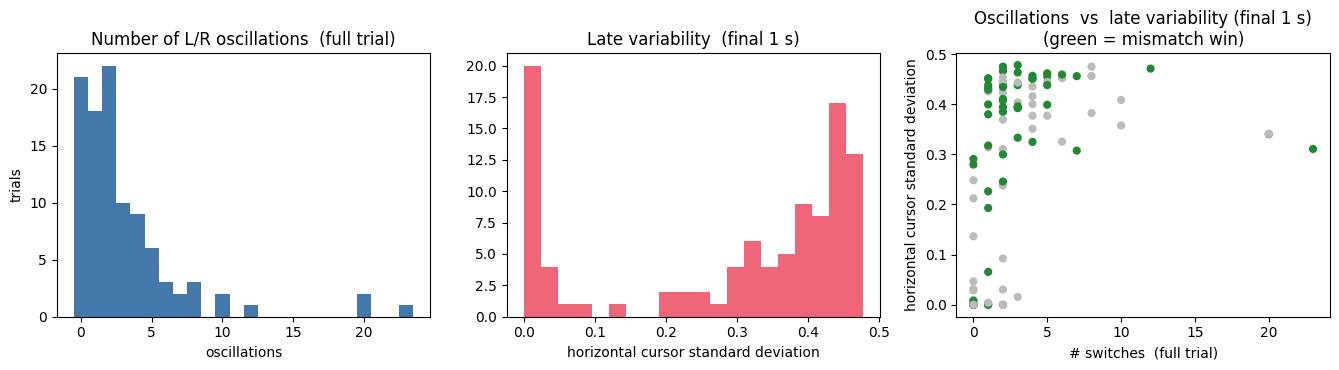

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8))

# [FULL TRIAL] number of L<->R switches across the whole trial
ax[0].hist(af.n_switch, bins=range(0, int(af.n_switch.max()) + 2), align="left", color="#4477aa")
ax[0].set(xlabel="oscillations", ylabel="trials",
          title="Number of L/R oscillations  (full trial)")

# [FINAL 1 s] cursor-x SD in the last 1 s before the random cutoff
ax[1].hist(af.x_std_last1s.dropna(), bins=20, color="#ee6677")
ax[1].set(xlabel="horizontal cursor standard deviation",
          title="Late variability  (final 1 s)")

# x = full-trial switches, y = final-1 s variability
colours = af.won.map({True: "#228833", False: "#bbbbbb"})
ax[2].scatter(af.n_switch, af.x_std_last1s, c=colours, s=24)
ax[2].set(xlabel="# switches  (full trial)",
          ylabel="horizontal cursor standard deviation",
          title="Oscillations  vs  late variability (final 1 s)\n(green = mismatch win)")
fig.tight_layout()

### One representative trajectory per category

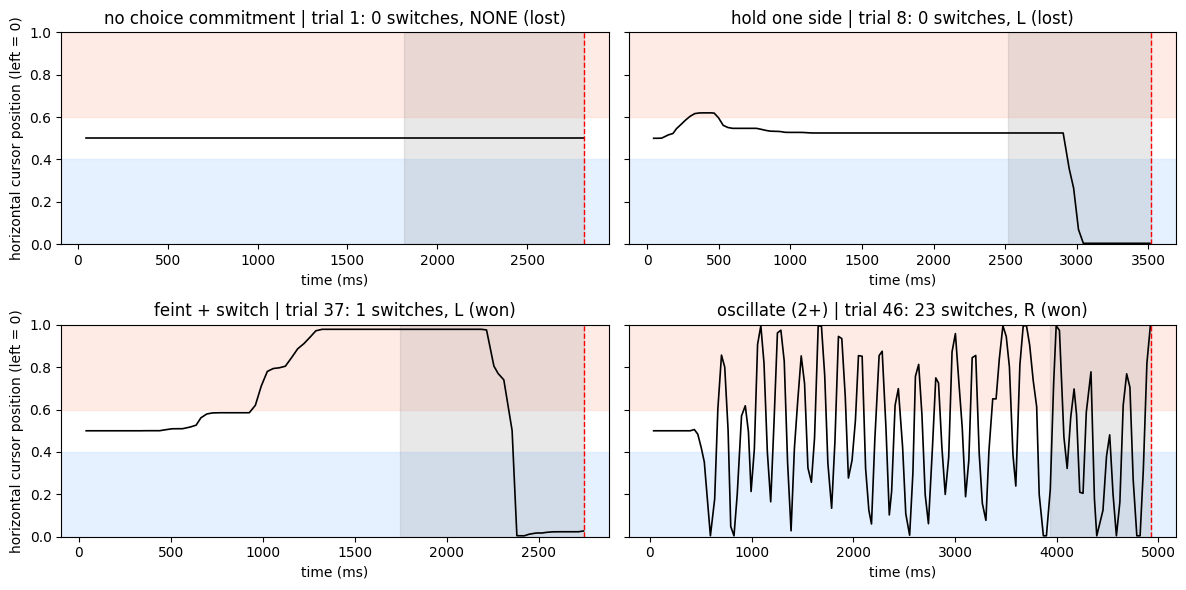

In [11]:
picks = {}
picks["no choice commitment"] = af[af.behaviour == "middle (no commit)"].index[0]
hold = af[(af.behaviour == "hold one side") & (af.final_zone != "NONE")]
picks["hold one side"] = hold.sort_values("x_std_all").index[0]
picks["feint + switch"] = af[af.behaviour == "feint + switch"].sort_values("peak_speed").index[-1]
picks["oscillate (2+)"] = af[af.behaviour == "oscillate (2+)"].sort_values("n_switch").index[-1]

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharey=True)
for ax_, (cat, tr) in zip(axes.ravel(), picks.items()):
    g = avoider[avoider.trial == tr].sort_values("t_ms")
    cutoff = mp.loc[tr, "random_time_ms"]
    ax_.axhspan(0.0, 0.40, color="#cce5ff", alpha=.5)            # L zone (approx)
    ax_.axhspan(0.60, 1.0, color="#ffd9cc", alpha=.5)            # R zone (approx)
    ax_.axvspan(cutoff - 1000, cutoff, color="grey", alpha=.18)  # the 'final 1 s' window
    ax_.plot(g.t_ms, g.x, color="k", lw=1.2)                     # full-trial trajectory
    ax_.axvline(cutoff, color="red", ls="--", lw=1)             # random cutoff
    won = "won" if af.loc[tr, "won"] else "lost"
    ax_.set(title=f"{cat} | trial {tr}: {int(af.loc[tr, 'n_switch'])} switches, "
                  f"{af.loc[tr, 'final_zone']} ({won})",
            xlabel="time (ms)", ylim=(0, 1))
axes[0, 0].set_ylabel("horizontal cursor position (left = 0)")
axes[1, 0].set_ylabel("horizontal cursor position (left = 0)")
# fig.suptitle("Avoider cursor trajectories (full trial)  —  "
#              "red dashed = random cutoff,  grey band = final-1 s window")
fig.tight_layout()

### First-pass findings

* **Oscillation is the avoider's default**: ~60% of trials had 2+ L&harr;R switches; only ~18% were a single feint-and-switch and ~15% a quiet hold. So *strategy 1 (back-and-forth) dominates* in raw frequency.
* **But the feint pays off best**: feint + switch won **~72%** of its trials, vs ~54% for oscillation, ~47% for holding, and **0%** for sitting in the middle (no commit = no valid choice = automatic loss). The single sudden switch beat the opponent more reliably than constant shuffling.
* **The hypothesis needs refining**: late cursor variability (`x_std_last1s`) is *bimodal* — a spike near 0 (settled) and a cluster near its max (still moving at cutoff) — but low late-variability alone is ambiguous: it lumps together *sitting in the middle*, *holding a side*, and *feint-and-hold*. The cleaner signature of a feint is **a single switch with a high peak speed** (one sharp late move), not low variability per se.

**Suggested next steps**
1. Contrast the avoider with the **matcher** on the same metrics (does only the avoider need to be unpredictable?).
2. Align trials to the cutoff and plot mean |velocity| vs *time-to-cutoff* — does the feint group show a late velocity burst?
3. Test for **predictability/sequential dependence** (does the avoider's L/R or switch pattern autocorrelate, letting the matcher exploit it?).
4. Relate strategy choice to trial **duration** — do longer (later-cutoff) trials push players from feint toward oscillation?